### SVM Classifier (Support Vector Machine)

Zastosowanie klasyfikatora SVM (Maszyna Wektorów Nośnych) poprzedzamy odpowiednim załadowaniem danych. W komórce poniżej dokonujemy selekcji cech, na podstawie których klasyfikator będzie decydował czy sygnał w danym oknie jest z anomalią. Zdecydowaliśmy się na te same 3 kluczowe cechy:
- qSQI (Correlation signal quality index)
- cSQI (Quality signal quality index)
- kSQI (Kurtosis signal quality index)

##### qSQI
Metryka oceniająca wiarygodność sygnału poprzez porównanie wyników dwóch niezależnych algorytmów detekcji zespołów QRS.

##### cSQI
Metryka oceniająca powtarzalność kształtu (morfologii) zespołów QRS w badanym oknie czasowym. 
Opiera się na założeniu, że zdrowe uderzenia serca u danego pacjenta wyglądają bardzo podobnie do siebie.

##### kSQI (Kurtoza)
Metryka statystyczna wykorzystująca czwarty moment centralny (kurtozę) do oceny rozkładu amplitud sygnału. Określa "szpilkowatość" wykresu – anomalie często mają bardzo wysoką lub bardzo niską kurtozę w porównaniu do normy.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC  
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import minmax_scale

data_dir = Path("dataset")

# Wczytanie danych
train_df = pd.read_pickle(data_dir / "dataset_train.pkl")
val_df = pd.read_pickle(data_dir / "dataset_val.pkl")

print("Dane wczytane.")

Dane wczytane.


In [ ]:

features = ['qSQI', 'cSQI', 'kurtosis']
targets = ['label']

X_train = train_df[features].values
y_train = train_df[targets].values.astype(int)

X_val = val_df[features].values
y_val = val_df[targets].values.astype(int)

# Filling nan values with mean values 
imputer = SimpleImputer(strategy="mean")
X_train_im = imputer.fit_transform(X_train)
X_val_im = imputer.transform(X_val)


scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train_im)
X_val_scaled = scaler.transform(X_val_im)

# Tworzenie modelu SVM
# kernel='rbf' to standard dla nieliniowych zależności
# C=1.0 domyślny parametr
svm_model = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)

print("Trenowanie modelu SVM...")
svm_model.fit(X_train_scaled, y_train.ravel())

# Predykcja
y_pred = svm_model.predict(X_val_scaled)

print("Raport klasyfikacji:")
print(classification_report(y_val, y_pred, target_names=['Valid (0)', 'Anomally (1)']))

Trenowanie modelu SVM...
Raport klasyfikacji:
              precision    recall  f1-score   support

   Valid (0)       0.76      0.87      0.81        30
Anomally (1)       0.76      0.62      0.68        21

    accuracy                           0.76        51
   macro avg       0.76      0.74      0.75        51
weighted avg       0.76      0.76      0.76        51



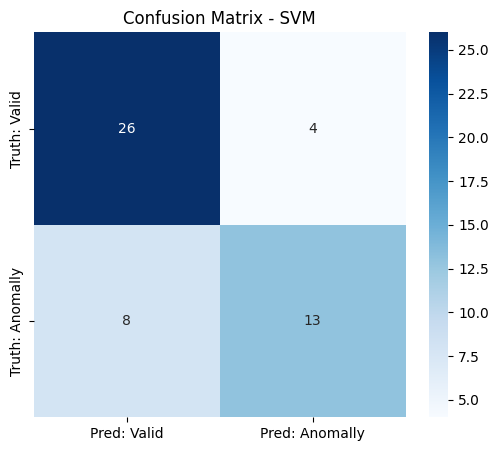

In [3]:
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Valid', 'Pred: Anomally'],
            yticklabels=['Truth: Valid', 'Truth: Anomally'])
plt.title('Confusion Matrix - SVM')
plt.show()

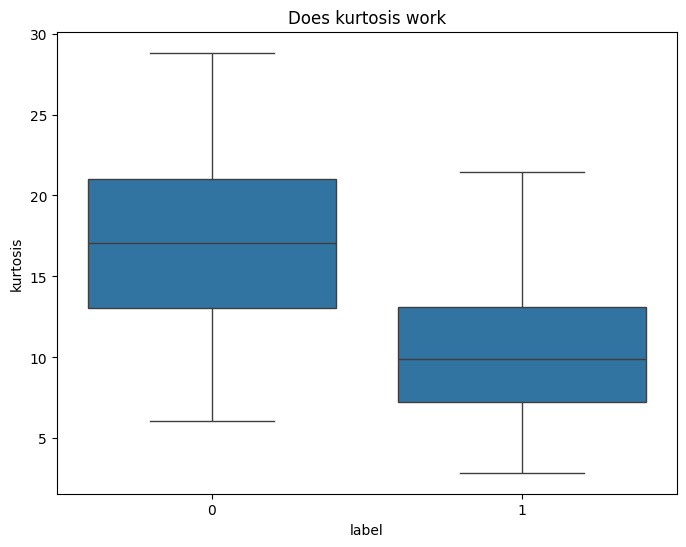

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.boxplot(x='label', y='kurtosis', data=train_df, showfliers=False) 
plt.title("Does kurtosis work")
plt.show()

### Wyszukiwanie najlepszych paramterow 

In [ ]:
from sklearn.model_selection import GridSearchCV

# Definiujemy siatkę parametrów dla SVM
# C: Regularyzacja 
# gamma: Zasięg wpływu pojedynczego punktu 
svm_params = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.1, 0.01, 0.001],
    'kernel': ['rbf'] 
}

print("Rozpoczynam Grid Search dla SVM...")
# n_jobs=-1 używa wszystkich procesorów, żeby było szybciej
svm_grid = GridSearchCV(SVC(), svm_params, cv=5, scoring='accuracy', n_jobs=-1)

svm_grid.fit(X_train_scaled, y_train.ravel())

best_params = svm_grid.best_params_
best_score = svm_grid.best_score_

print(f"Najlepsze parametry: {best_params}")
print(f"Najlepsza dokładność (CV): {best_score:.2%}")

Rozpoczynam Grid Search dla SVM...
Najlepsze parametry: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Najlepsza dokładność (CV): 76.38%


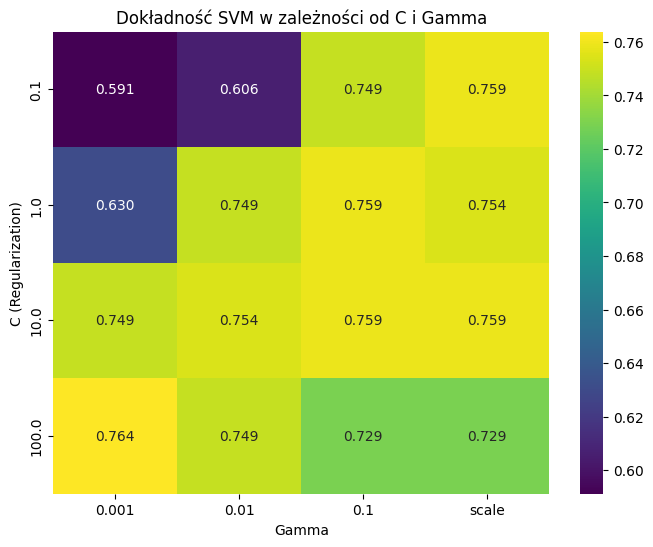

In [6]:
# Pobieramy wyniki do DataFrame
results_df = pd.DataFrame(svm_grid.cv_results_)

# Przygotowujemy dane do heatmapy (oś X: gamma, oś Y: C)
# Wyciągamy param_C i param_gamma z wyników
heatmap_data = results_df.pivot(index='param_C', columns='param_gamma', values='mean_test_score')

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt='.3f')
plt.title('Dokładność SVM w zależności od C i Gamma')
plt.xlabel('Gamma')
plt.ylabel('C (Regularization)')
plt.show()

In [7]:
best_svm = svm_grid.best_estimator_

print(f"Final accuracy on Validation Set: {best_svm.score(X_val_scaled, y_val):.2%}")

y_pred = best_svm.predict(X_val_scaled)
print(classification_report(y_val, y_pred, target_names=['Valid (0)', 'Anomally (1)']))

Final accuracy on Validation Set: 76.47%
              precision    recall  f1-score   support

   Valid (0)       0.76      0.87      0.81        30
Anomally (1)       0.76      0.62      0.68        21

    accuracy                           0.76        51
   macro avg       0.76      0.74      0.75        51
weighted avg       0.76      0.76      0.76        51



In [8]:
lengths = train_df['sygnał'].apply(len)
print("Signal lenghts")
print(lengths.value_counts())

Signal lenghts
sygnał
1280    203
Name: count, dtype: int64


In [9]:
def filter_lenght(df):
    print(len(df['sygnał']))
    df_filtered = df[df['sygnał'].apply(len) == 1280].copy()
    df_filtered.reset_index(drop=True, inplace=True)

    return df_filtered

In [10]:
train_df = filter_lenght(train_df)
val_df = filter_lenght(val_df)

203
51


In [11]:
def create_clean_dataset(df, target_len=1280):
    
    clean_signals = []
    clean_labels = []
    
    for _, row in df.iterrows():
  
        sig = np.array(row['sygnał'])
        
        if row['źródło'] == 'kliniczne':
            sig = sig[:,1]
            
        sig = sig.flatten()
        

        if sig.shape[0] == target_len:
            clean_signals.append(sig)
            clean_labels.append(row['label'])

    
    X = np.stack(clean_signals)
    y = np.array(clean_labels).astype(int)
    
    return X, y

In [12]:
X_train_raw, y_train = create_clean_dataset(train_df)
X_val_raw, y_val = create_clean_dataset(val_df)

In [ ]:

features = ['sygnał']
targets = ['label']


imputer = SimpleImputer(strategy="mean")
X_train_im = imputer.fit_transform(X_train_raw)
X_val_im = imputer.transform(X_val_raw)

# Skalowanie 
X_train_scaled = minmax_scale(X_train_im, axis=1)
X_val_scaled = minmax_scale(X_val_im, axis=1)

# svm na surowym
# Używamy domyślnego jądra
svm_raw = SVC(kernel='rbf', C=1.0, probability=True)

print("Trenowanie SVM na surowym sygnale (to może chwilę potrwać)...")
svm_raw.fit(X_train_scaled, y_train.ravel())

# Predykcja
y_pred_raw = svm_raw.predict(X_val_scaled)

print("Wyniki SVM na surowym sygnale:")
print(classification_report(y_val, y_pred_raw, target_names=['Valid (0)', 'Anomally (1)']))

Trenowanie SVM na surowym sygnale (to może chwilę potrwać)...
Wyniki SVM na surowym sygnale:
              precision    recall  f1-score   support

   Valid (0)       0.79      0.90      0.84        30
Anomally (1)       0.82      0.67      0.74        21

    accuracy                           0.80        51
   macro avg       0.81      0.78      0.79        51
weighted avg       0.81      0.80      0.80        51



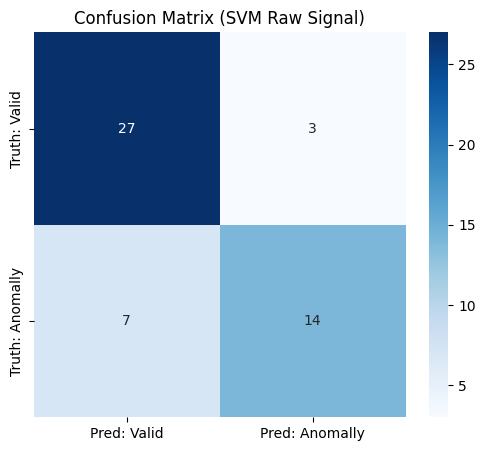

In [14]:
cm = confusion_matrix(y_val, y_pred_raw)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Valid', 'Pred: Anomally'],
            yticklabels=['Truth: Valid', 'Truth: Anomally'])
plt.title('Confusion Matrix (SVM Raw Signal)')
plt.show()